In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder,RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report,accuracy_score

In [49]:
df=pd.read_csv("data/hypertension.csv")
df.head()

,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


# Preprocessing

In [50]:
# Finding unique values in the dataset(Catgorical features)
print(df.BP_History.unique())
print(df.Medication.unique())
print(df.Exercise_Level.unique())
print(df.Smoking_Status.unique())
print(df.Family_History.unique())

['Normal' 'Hypertension' 'Prehypertension']
[nan 'ACE Inhibitor' 'Other' 'Beta Blocker' 'Diuretic']
['Low' 'Moderate' 'High']
['Non-Smoker' 'Smoker']
['Yes' 'No']


In [51]:
# Checking null and duplicate values

print(f"Null values: {df.isnull().sum()}")
print(f"Duplicate values: {df.duplicated().sum()}")

Null values: Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64
Duplicate values: 0


In [52]:
# Cleaning data and changing the column values to numeric

# DF.Medication (Cleaning)
df.Medication=df.Medication.fillna('No')
df.Medication=df.Medication.apply(lambda x: 0 if x == 'No' else 1)
print(f"Unique values in Medication: {df.Medication.unique()}")

#DF.BP_History (Cleaning)
o_encoder_bp = OrdinalEncoder(categories=[['Normal','Prehypertension','Hypertension']])
df.BP_History = o_encoder_bp.fit_transform(df[['BP_History']]).astype(int)
print(f"Unique values in BP_History: {df.BP_History.unique()}")

#DF.Exercise_Level (Cleaning)
o_encoder_exercise = OrdinalEncoder(categories=[['Low','Moderate','High']])
df.Exercise_Level = o_encoder_exercise.fit_transform(df[['Exercise_Level']]).astype(int)
print(f"Unique values in Exercise_Level: {df.Exercise_Level.unique()}")

# DF.Smoking_Status (Cleaning)
df.Smoking_Status=df.Smoking_Status.map({'Non-Smoker':0,'Smoker':1})
print(f"Unique values in Smoking_Status: {df.Smoking_Status.unique()}")

#DF.Family_History (Cleaning)
df.Family_History=df.Family_History.map({'No':0,'Yes':1})
print(f"Unique values in Family_History: {df.Family_History.unique()}")

#DF.Has_Hypertension (Cleaning)
df.Has_Hypertension=df.Has_Hypertension.map({'No':0,'Yes':1})
print(f"Unique values in Has_Hypertension: {df.Has_Hypertension.unique()}")


Unique values in Medication: [0 1]
Unique values in BP_History: [0 2 1]
Unique values in Exercise_Level: [0 1 2]
Unique values in Smoking_Status: [0 1]
Unique values in Family_History: [1 0]
Unique values in Has_Hypertension: [1 0]


# EDA

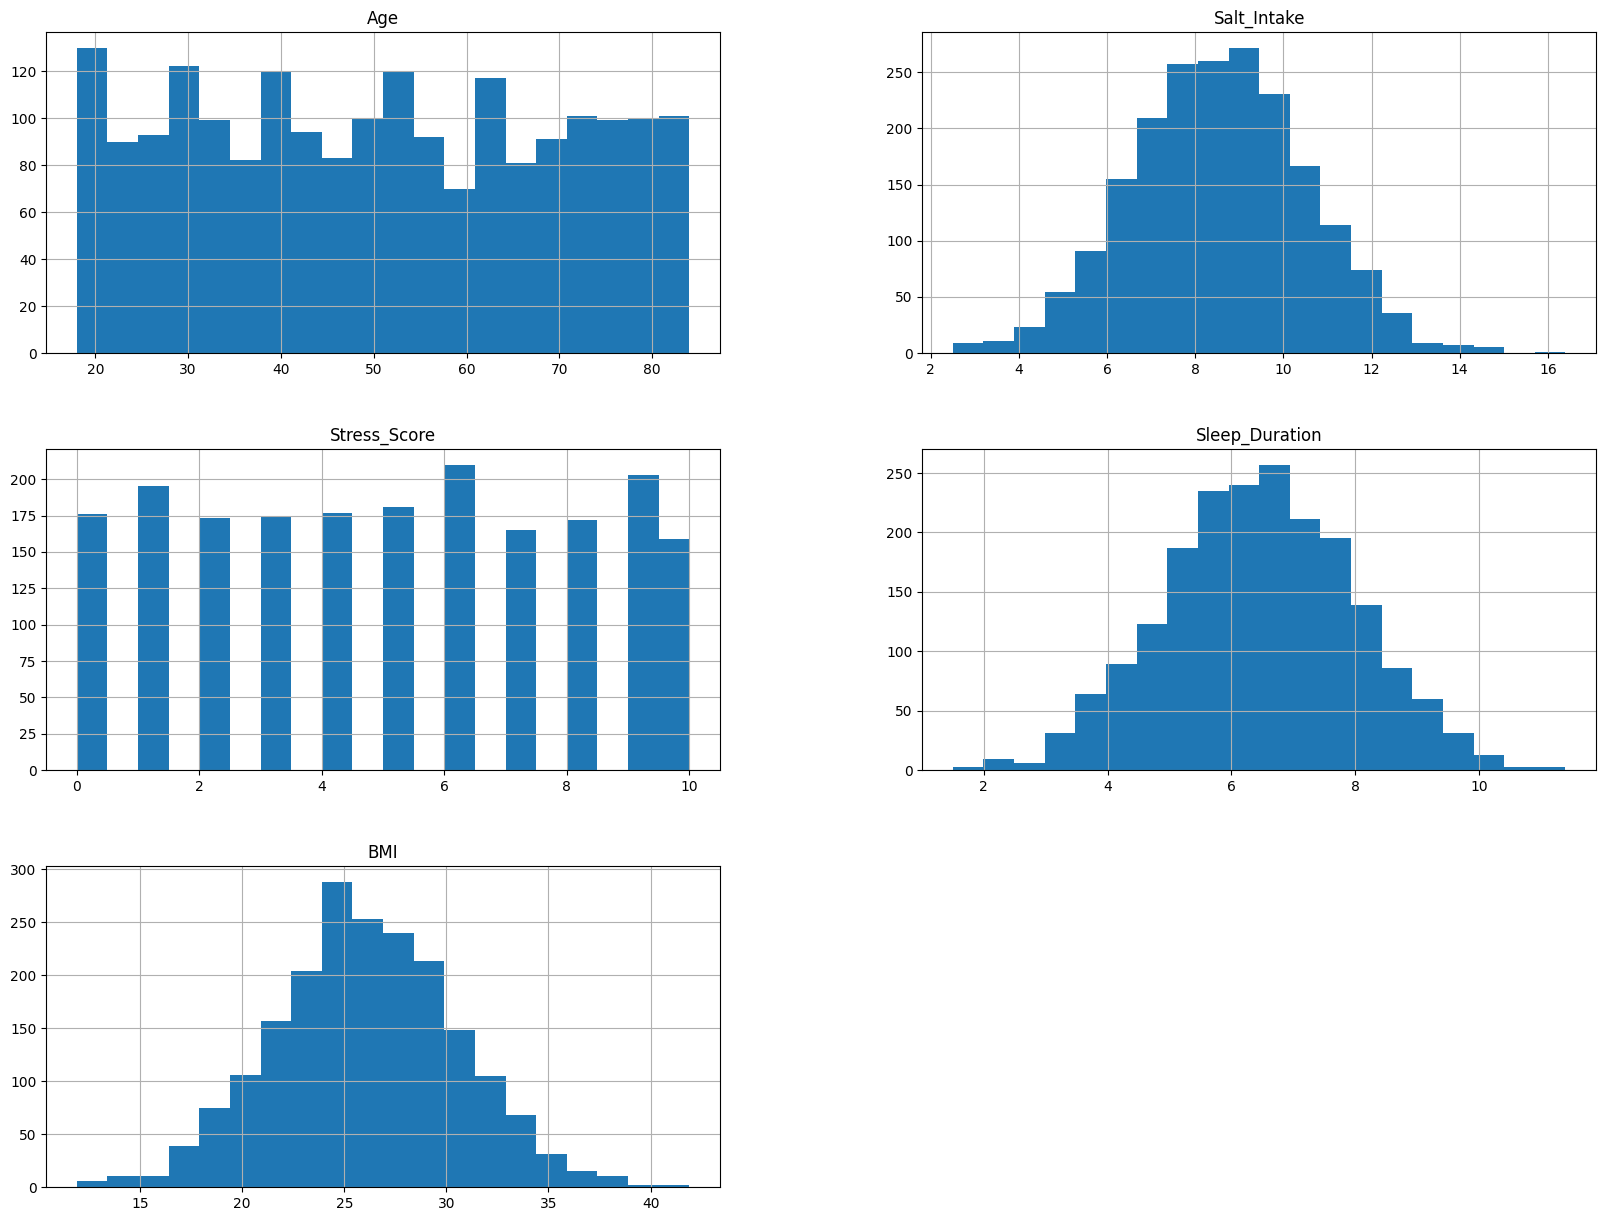

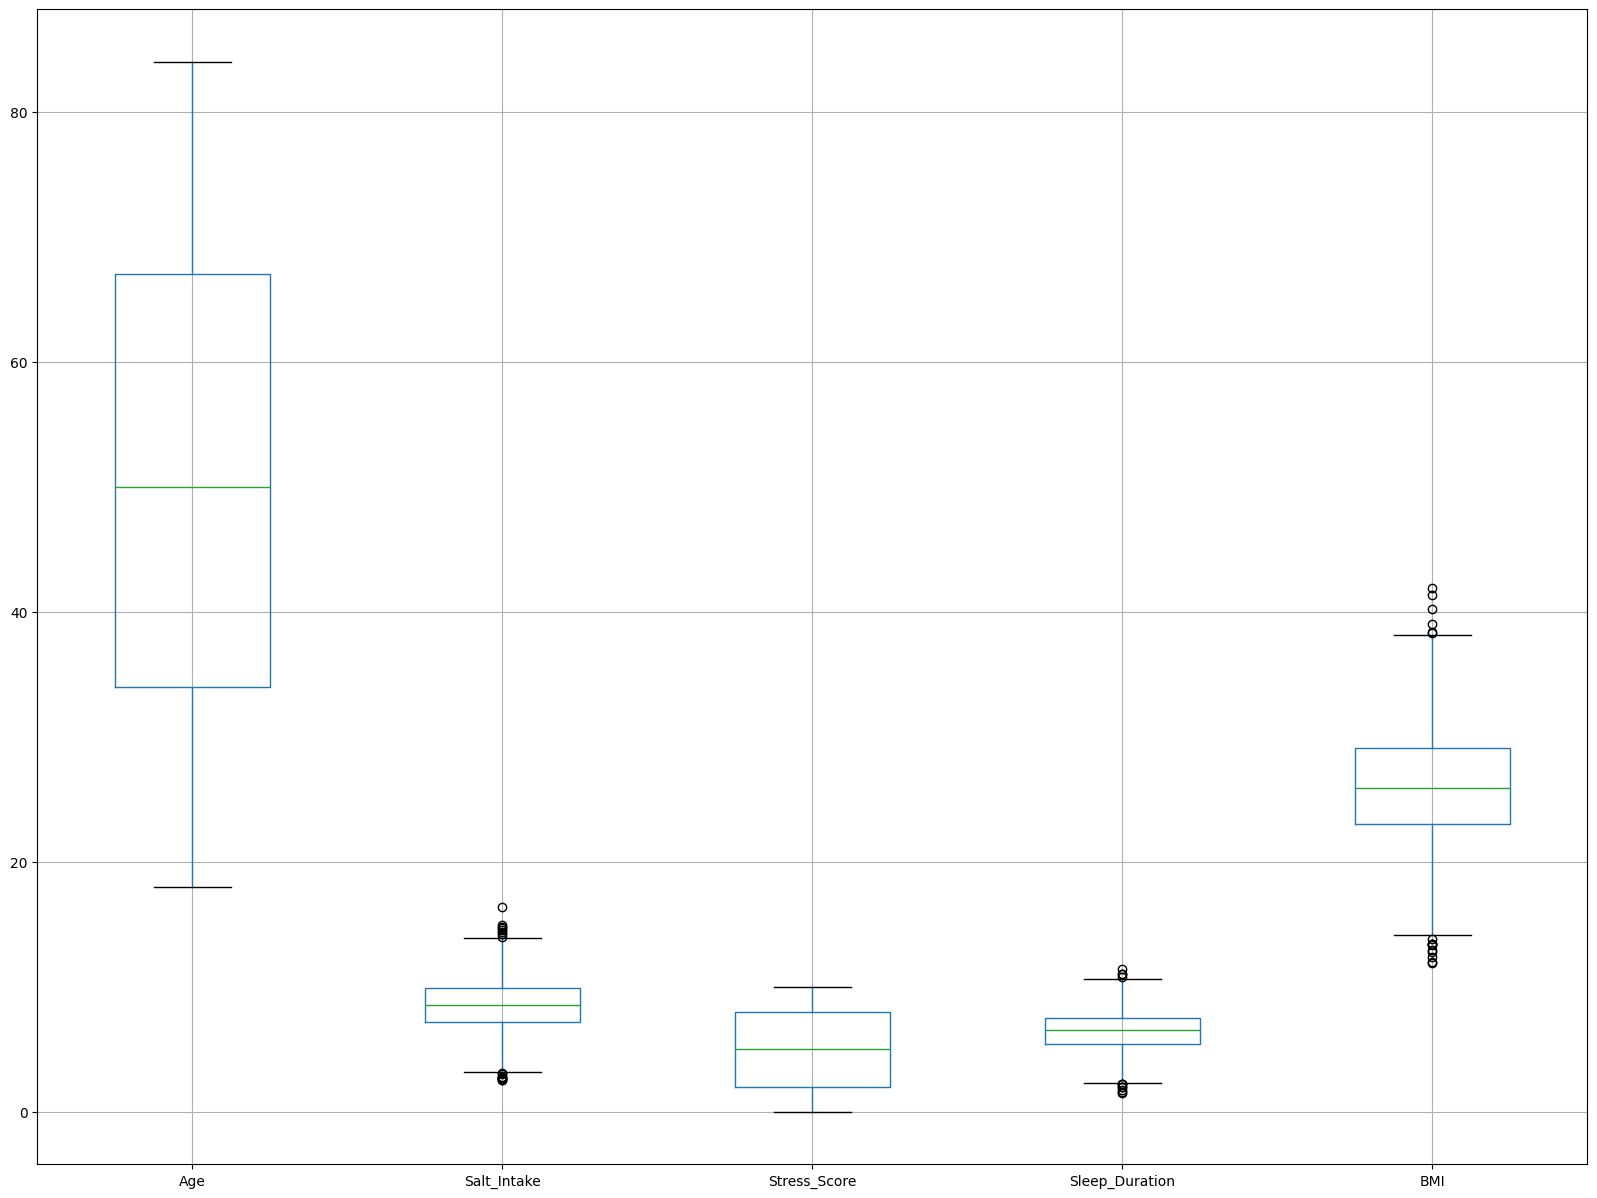

In [53]:
num_cols=['Age','Salt_Intake','Stress_Score','Sleep_Duration','BMI',]
cat_cols=['Medication','BP_History','Exercise_Level','Smoking_Status','Family_History']
target='Has_Hypertension'

df[num_cols].hist(bins=20, figsize=(20,15))
plt.show()

df[num_cols].boxplot(figsize=(20,15))
plt.show()

In [54]:
# Feature Engineering
x=df.drop(columns=['Has_Hypertension'])
y=df['Has_Hypertension']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Scaling with RobustScaler without clipping because of slight outliers
scaler=RobustScaler()
x_train[num_cols]=scaler.fit_transform(x_train[num_cols])
x_test[num_cols]=scaler.transform(x_test[num_cols])

# Train Model

In [55]:
# Decision Tree
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
y_pred=dt.predict(x_test)

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")
print(classification_report(y_test,y_pred))

Accuracy Score: 0.9546599496221663
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       192
           1       0.95      0.97      0.96       205

    accuracy                           0.95       397
   macro avg       0.96      0.95      0.95       397
weighted avg       0.95      0.95      0.95       397



In [56]:
# Random Forest
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")
print(classification_report(y_test,y_pred))

Accuracy Score: 0.9571788413098237
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       192
           1       0.97      0.95      0.96       205

    accuracy                           0.96       397
   macro avg       0.96      0.96      0.96       397
weighted avg       0.96      0.96      0.96       397



In [57]:
# Gradient Boosting
gb=GradientBoostingClassifier()
gb.fit(x_train,y_train)
y_pred=gb.predict(x_test)

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")
print(classification_report(y_test,y_pred))


Accuracy Score: 0.9874055415617129
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       192
           1       0.99      0.99      0.99       205

    accuracy                           0.99       397
   macro avg       0.99      0.99      0.99       397
weighted avg       0.99      0.99      0.99       397



In [58]:
# XGBoost
xgb=XGBClassifier()
xgb.fit(x_train,y_train)
y_pred=xgb.predict(x_test)

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")
print(classification_report(y_test,y_pred))

Accuracy Score: 0.9924433249370277
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       192
           1       1.00      0.99      0.99       205

    accuracy                           0.99       397
   macro avg       0.99      0.99      0.99       397
weighted avg       0.99      0.99      0.99       397



In [59]:
# LightGBM
lgb=LGBMClassifier()
lgb.fit(x_train,y_train)
y_pred=lgb.predict(x_test)

print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")
print(classification_report(y_test,y_pred))

[LightGBM] [Info] Number of positive: 827, number of negative: 761
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000171 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 448
[LightGBM] [Info] Number of data points in the train set: 1588, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.520781 -> initscore=0.083171
[LightGBM] [Info] Start training from score 0.083171
Accuracy Score: 0.9924433249370277
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       192
           1       1.00      0.99      0.99       205

    accuracy                           0.99       397
   macro avg       0.99      0.99      0.99       397
weighted avg       0.99      0.99      0.99       397



## Model Selection
Based on the performance analysis, we decided to select Extreme Gradient Boosting (XGBoost) for prediction.

In [61]:
# Save the model and scaler

with open('models/hypertension_xgb_model.pkl', 'wb') as file:
    pickle.dump(xgb, file)

with open('models/hypertension_o_encoder_bp.pkl', 'wb') as file:
    pickle.dump(o_encoder_bp, file)

with open('models/hypertension_o_encoder_exercise.pkl', 'wb') as file:
    pickle.dump(o_encoder_exercise, file)

with open('models/hypertension_scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

# Inference

In [4]:
# Loading model, encoder and scaler
model=pickle.load(open('models/hypertension_xgb_model.pkl', 'rb'))
o_encoder_bp=pickle.load(open('models/hypertension_o_encoder_bp.pkl', 'rb'))
o_encoder_exercise=pickle.load(open('models/hypertension_o_encoder_exercise.pkl', 'rb'))
scaler=pickle.load(open('models/hypertension_scaler.pkl', 'rb'))

In [10]:
def predict(data):
    df=pd.DataFrame([data])

    # ---- Required features check ----
    required = ['Salt_Intake', 'BMI', 'BP_History']
    for col in required:
        if col not in df.columns or pd.isna(df[col]).iloc[0]:
            return {"error": "data not enough information"}

    df['Age'] = df['Age'].fillna(22)
    df['Stress_Score'] = df['Stress_Score'].fillna(5)
    df['Sleep_Duration'] = df['Sleep_Duration'].fillna(6)
    df['Medication'] = df['Medication'].fillna('No')
    df['Exercise_Level'] = df['Exercise_Level'].fillna('Moderate')
    df['Smoking_Status'] = df['Smoking_Status'].fillna('Non-Smoker')
    df['Family_History'] = df['Family_History'].fillna('No')

    # ---- Encoding ----
    df['Medication'] = df['Medication'].apply(lambda x: 0 if x == 'No' else 1)
    df['BP_History'] = o_encoder_bp.transform(df[['BP_History']]).astype(int)
    df['Exercise_Level'] = o_encoder_exercise.transform(df[['Exercise_Level']]).astype(int)
    df['Smoking_Status'] = df['Smoking_Status'].map({'Non-Smoker': 0, 'Smoker': 1})
    df['Family_History'] = df['Family_History'].map({'No': 0, 'Yes': 1})

    # Identify columns
    num_cols = ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI']
    cat_cols = ['Medication', 'BP_History', 'Exercise_Level', 'Smoking_Status', 'Family_History']

    # Scale numeric columns only
    df[num_cols] = scaler.transform(df[num_cols])

    # Predict
    pred = model.predict(df)[0]

    # Decode result
    result = "Hypertension" if pred == 1 else "No Hypertension"
    return {"prediction": int(pred), "result": result}

In [13]:
data={
  "Age": 54,
  "Salt_Intake": 9.2,
  "Stress_Score": 6,
  "BP_History": "Prehypertension",
  "Sleep_Duration": 6.8,
  "BMI": 27.4,
  "Medication": "ACE Inhibitor",
  "Family_History": "Yes",
  "Exercise_Level": "Moderate",
  "Smoking_Status": "Smoker"
}

print(predict(data))

{'prediction': 1, 'result': 'Hypertension'}


In [16]:
from hypertension_llm_extractor import LabReportExtractor
from my_secrets import api_key

report_extractor = LabReportExtractor(api_key)

lab_text = """
Patient Name: John Mathew
Age: 54 years, Male.
BMI: 27.4 kg/m²
Average daily salt intake reported: around 9 grams per day.
Sleep duration: 6.8 hours per night.

Stress score from questionnaire: 6/10.
Blood pressure history: Patient has been in the "Prehypertension" range for the last 2 years.

Exercise: Moderate physical activity, jogging 3 times a week.
Smoking status: Occasional smoker (social smoker).

Medication: Currently taking ACE inhibitor as prescribed.
Family history: Father had hypertension.
"""

data = report_extractor.extract(lab_text)
print(data)

{'Age': 54, 'Salt_Intake': 9, 'Stress_Score': 6, 'BP_History': 'Prehypertension', 'Sleep_Duration': 6.8, 'BMI': 27.4, 'Medication': 'ACE inhibitor', 'Family_History': 'Yes', 'Exercise_Level': 'Moderate', 'Smoking_Status': 'Smoker'}


In [17]:
predict(data)

{'prediction': 1, 'result': 'Hypertension'}